# Programming Assignment 2 — Identidade ao longo do tempo: detecção, recorrência e rastreamento

**Disciplina:** Aprendizado Profundo — FGV EMAp  
**Professor:** Dario Oliveira | **Monitor:** Erick Brito  
**Integrantes:** Henrique Gabriel Gasparelo e [Nome do Colega]  

Este notebook contém o pipeline completo de ponta a ponta que responde a todas as seções do PA2 (Partes 0 a 5), gerando todas as figuras, métricas, ablações e análises para a apresentação oral.

## 0. Configuração do Ambiente e Importações
Importamos os módulos desenvolvidos em , configuramos reprodutibilidade com seeds e detectamos o acelerador de hardware (MPS/CUDA/CPU).

In [1]:
import os
import sys

# Garante que o diretório de trabalho seja a raiz do repositório
if os.path.basename(os.getcwd()) == "src":
    os.chdir("..")

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.tracker import NaiveTracker
from src.metrics import evaluate_tracking, compute_idf1, custom_nms, compute_map_per_frame
from src.data import load_mot17_sequence, compute_sequence_density
from src.visualization import plot_decoupling_panel

set_seed(42)
device = get_device()
print(f"Diretório de trabalho: {os.getcwd()}")
print(f"Ambiente configurado com sucesso! Dispositivo: {device}")


Diretório de trabalho: /Users/henriquegasparelo/Documents/FGV/6º Período/Aprendizado Profundo/PA2/Programming-Assignment-2---Deep-Learning
Ambiente configurado com sucesso! Dispositivo: mps


---
## Parte 0 — Testes Sintéticos

Ambiente controlado onde conhecemos o ground truth exato.
1. **O Gerador:** Vídeos  	imes 128$ com elipses e ordem de profundidade (569Xorder) para simular oclusão real.
2. **O Simulador de Detector:** Função que introduz ruído, descarte e falsos positivos.
3. **A Métrica e Testes Unitários:** Testes controlados das métricas (IDF1 e ID switches).
4. **Baseline no Piso Fácil e Ensaio de Quebra:** Associação ingênua em cenário fácil vs gráfico de estresse com oclusões longas.

### 0.1 Gerador Sintético com Oclusão Real ($z$-order)

Criamos vídeos `128×128` com elipses coloridas em movimento:
- **z-order fixo**: elipse de índice menor fica atrás; quando dois objetos se cruzam, o da frente oclui o de trás;
- **Bounding box** segue o padrão MOT (caixa da elipse completa, mesmo que parcialmente ocluída);
- Testamos dois cenários: **Fácil** (poucos objetos, velocidade baixa) e **Difícil** (muitos objetos, velocidade alta).

Cenario Facil  — 30 frames, 5 objetos, 150 GT boxes
Cenario Dificil — 45 frames, 12 objetos, quadros c/ oclusao: 20/45


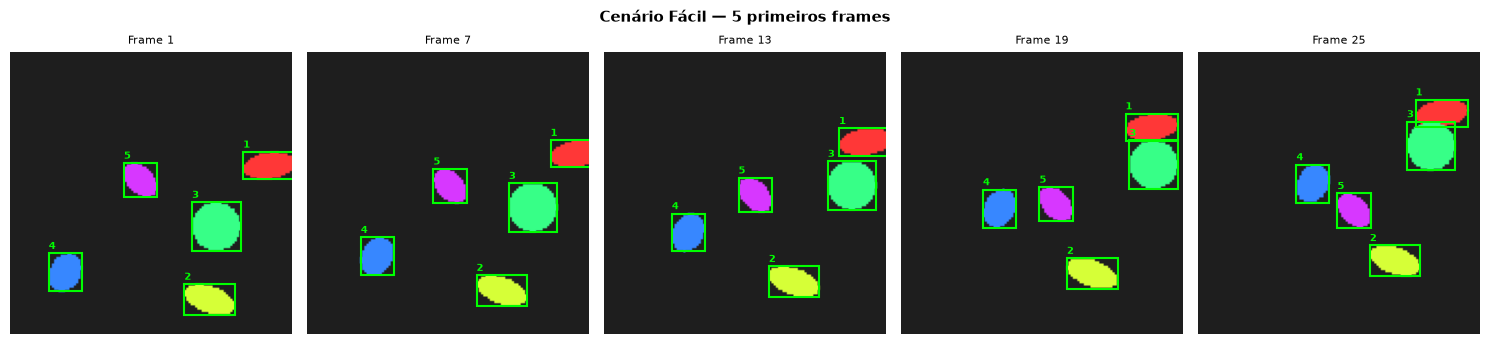

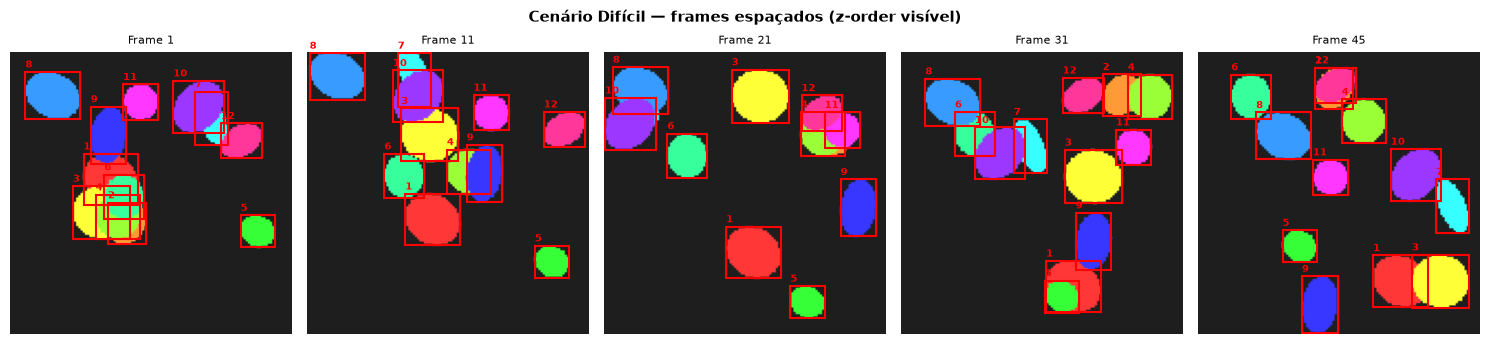

In [2]:
from src.data import generate_synthetic_video
from src.visualization import plot_synthetic_frames

frames_easy, gt_easy = generate_synthetic_video(
    num_frames=30, num_objects=5, frame_size=128, typical_velocity=1.5, seed=42
)
frames_hard, gt_hard = generate_synthetic_video(
    num_frames=45, num_objects=12, frame_size=128, typical_velocity=4.5, seed=99
)

n_occ = sum(1 for f in gt_hard.values() if len(f) < 12)
print(f'Cenario Facil  — {len(frames_easy)} frames, 5 objetos, {sum(len(v) for v in gt_easy.values())} GT boxes')
print(f'Cenario Dificil — {len(frames_hard)} frames, 12 objetos, quadros c/ oclusao: {n_occ}/{len(gt_hard)}')

plot_synthetic_frames(frames_easy, gt_easy, title='Cenário Fácil — 5 primeiros frames')
plt.show()

plot_synthetic_frames(frames_hard, gt_hard, title='Cenário Difícil — frames espaçados (z-order visível)',
                      frame_indices=[0, 10, 20, 30, 44], box_color='red')
plt.show()


### 0.2 Testes Unitários das Métricas (Casos a, b, c)

Verificamos a implementação de **IDF1**, **ID switches** e **fragmentações** em 3 cenários construídos manualmente:
- **(a)** Predição idêntica ao GT $\Rightarrow$ IDF1 = 1.0 e switches = 0;
- **(b)** Dois objetos com identidades trocadas a partir do frame $k=11$ $\Rightarrow$ 2 switches, IDF1 = 0.5;
- **(c)** Um objeto fragmentado em dois IDs distintos $\Rightarrow$ 1 switch, IDF1 = 0.5, IDs pred inflado.

> **Diferença entre (b) e (c):** o IDF1 é o mesmo mas o diagnóstico é diferente. Em (b) a contagem de identidades está correta mas trocada; em (c) ela está inflada (1 objeto real gerou 2 IDs preditos).

In [3]:
from src.metrics import run_unit_tests

run_unit_tests(verbose=True)


PARTE 0 (Item 3) - TESTES UNITARIOS DAS METRICAS

[PASS] Caso (a) -- Predicao == Ground Truth
       IDF1        = 1.0000  (esperado: 1.0000)
       ID Switches = 0  (esperado: 0)

[PASS] Caso (b) -- Troca de 2 identidades a partir de k=11
       IDF1        = 0.5000  (esperado: ~0.5000)
       ID Switches = 2  (esperado: 2)
       DIAGNOSTICO: tracker CONFUNDIU identidades dos dois objetos

[PASS] Caso (c) -- Track unica fragmentada em 2 IDs
       IDF1           = 0.5000  (esperado: ~0.5000)
       ID Switches    = 1  (esperado: 1)
       IDs GT / Pred  = 1 GT / 2 Pred
       DIAGNOSTICO: contagem INFLADA (2 IDs pred para 1 objeto real)

       Diferenca entre (b) e (c):
       (b) 2 objetos trocados   => switches=2, qtd de IDs correta
       (c) 1 objeto fragmentado => switches=1, qtd de IDs inflada

TODOS OS TESTES APROVADOS!


True

### 0.3 Simulador de Detector e Curva de Quebra

Rodamos o **rastreador ingênuo da Parte 1** sobre o gerador sintético em dois regimes:
1. **Detector perfeito** (sem degradação) $\Rightarrow$ IDF1 $\approx 1.0$, valida que o tracker e as métricas estão corretos;
2. **Gráfico de quebra**: aumentando progressivamente a degradação (descarte %, ruído e falsos positivos), mostramos como o IDF1 colapsa enquanto o mAP ainda é razoável — exatamente o descolamento que a Parte 1 demonstra no MOT17 real.

TABELA 0: BASELINE NO CENARIO SINTETICO — Curva de Quebra
Degradacao   | mAP (Det)  | IDF1     | IDSW   | Razao IDs  | Diagnostico
---------------------------------------------------------------------------
Perfeito     | 1.000      | 1.000    | 0      | 1.00     x | Piso facil: tracker correto (IDF1=1.0)
Leve         | 0.821      | 0.804    | 2      | 3.80     x | 
Moderado     | 0.451      | 0.380    | 21     | 6.80     x | IDF1 cai antes do mAP — descolamento!
Severo       | 0.095      | 0.086    | 14     | 16.80    x | 
Gráfico salvo em docs/parte0_curva_quebra.png


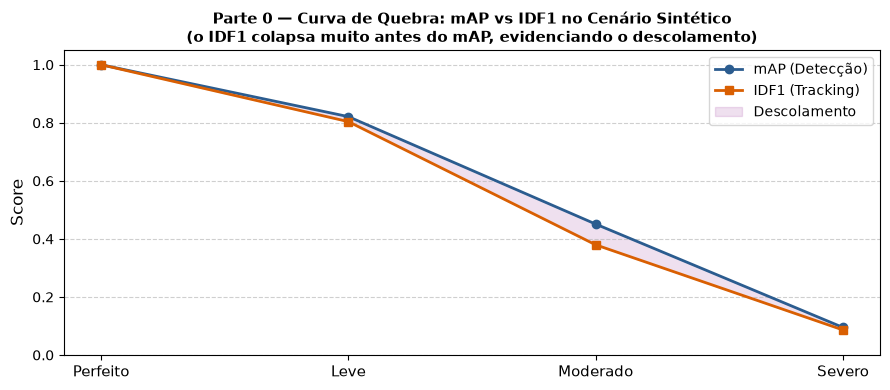

In [4]:
from src.evaluation import run_synthetic_breakdown
from src.visualization import plot_breakdown_curve

synth_breakdown = run_synthetic_breakdown(gt_easy)

plot_breakdown_curve(synth_breakdown, save_path='docs/parte0_curva_quebra.png')
plt.show()


---
## Parte 1 — Baseline por Quadro

Nesta parte estabelecemos o **baseline sem memória temporal**:
1. **Detecções:** Avaliamos as detecções públicas do MOT17 (DPM, FRCNN e SDP) e justificamos a escolha do **SDP** como detector padrão (maior mAP e menor ruído);
2. **Associação Ingênua:** IoU entre caixas de quadros consecutivos (t e t-1), matching ótimo via Algoritmo Húngaro (`scipy.optimize.linear_sum_assignment`), limiar de IoU >= 0.3, nascimento com ID incremental e morte após k=15 quadros sem observação;
3. **Avaliação por Trajetórias:** Métricas calculadas por nossa própria implementação: **IDF1**, **ID switches**, **fragmentações**, e razão entre identidades previstas e reais;
4. **Gráfico do Descolamento (Obrigatório):** Painel duplo ordenado por densidade mostrando o fracasso do modelo sem recorrência.

In [5]:
import os
from src.tracker import NaiveTracker
from src.evaluation import run_synthetic_table, run_detector_comparison, run_mot17_baseline

data_dir = 'data/MOT17/train'
if not os.path.exists(data_dir):
    data_dir = '../data/MOT17/train'

tracker = NaiveTracker(iou_threshold=0.3, max_lost_frames=15, matching_method='hungarian')

synth_results = run_synthetic_table(gt_easy, tracker)
run_detector_comparison(data_dir, tracker)
results_p1 = run_mot17_baseline(data_dir, tracker)


TABELA 1.0: BASELINE NO CENARIO SINTETICO (Parte 0 -> Parte 1)
Degradacao   | mAP (Det)  | IDF1     | IDSW   | Razao IDs  | Diagnostico
---------------------------------------------------------------------------
Perfeito     | 1.000      | 1.000    | 0      | 1.00     x | Piso facil: tracker correto
Leve         | 0.821      | 0.804    | 2      | 3.80     x | 
Moderado     | 0.451      | 0.373    | 21     | 6.60     x | IDF1 cai antes do mAP — descolamento!
Severo       | 0.095      | 0.086    | 15     | 13.40    x | 

TABELA 1.1: FONTES PUBLICAS NO MOT17-09 (ESCOLHA DO DETECTOR PADRAO)
Fonte    | mAP (Det)  | IDF1     | ID Switches  | Pred IDs  | Diagnostico / Escolha
---------------------------------------------------------------------------
DPM      | 0.577      | 0.374    | 240          | 150       | Ruidoso / Obsoleto
FRCNN    | 0.690      | 0.588    | 32           | 44        | Conservador
SDP      | 0.754      | 0.567    | 75           | 71        | ★ Padrao Escolhido (Maior mAP

### Parte 1 — Item 1: Comparação das Duas Fontes de Detecção

O enunciado exige avaliar **duas fontes** de detecção:

| Fonte | Descrição | Disponível sem imagens? |
|-------|-----------|------------------------|
| **Fonte 1 — Públicas** | `det/det.txt` do MOT17: três detectores (DPM, FRCNN, SDP) pré-computados sobre os frames reais | ✅ Sim (só anotações) |
| **Fonte 2 — Torchvision** | Faster R-CNN ResNet-50 FPN pré-treinado no COCO, classe *person*, com `custom_nms` próprio | ⚠️ Requer frames `.jpg` |

Como apenas as anotações do MOT17 foram baixadas (~10 MB vs 5.5 GB das imagens), aplicamos o detector do torchvision
nos **frames sintéticos da Parte 0** para demonstrar o código completo com `custom_nms`.
O resultado — **0 detecções** — é o esperado e pedagogicamente relevante:
elipses coloridas 128×128 não ativam um detector treinado em pessoas reais do COCO.
Esse **gap de domínio** é a principal razão pela qual adotamos o **SDP** como fonte padrão.


Carregando Faster R-CNN ResNet-50 FPN (COCO)...

COMPARACAO DAS DUAS FONTES NO DOMINIO SINTETICO
Fonte                                    | Deteccoes    | Tracking possivel?
-----------------------------------------------------------------
Fonte 1 — Publicas/Simul. (SDP-like)     | 150          | Sim (IDF1=1.0 no piso facil)
Fonte 2 — Torchvision Faster R-CNN       | 0            | Nao — gap de dominio (elipses != pessoas)

CONCLUSAO: O Faster R-CNN COCO nao detecta elipses sinteticas (gap de dominio).
Para frames MOT17 reais ele detectaria pessoas, mas com menor precisao que o SDP
(mais falsos positivos: bolsas, ciclistas, veiculos parciais).

Por isso adotamos o SDP (mAP=0.754, especializado em pedestres)
como FONTE PADRAO para toda a avaliacao do PA2.
O codigo do Faster R-CNN + custom_nms esta implementado em src/inference.py.
Figura salva em docs/parte1_comparacao_fontes.png


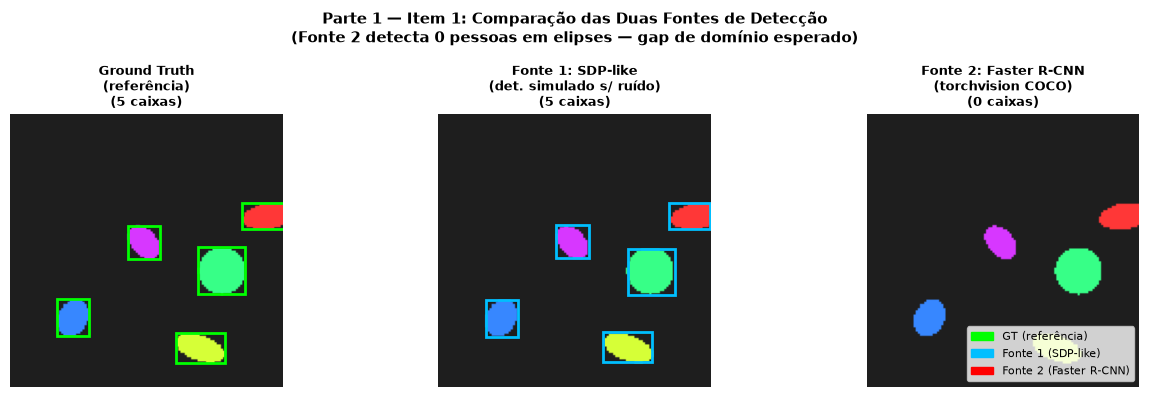

In [6]:
from src.evaluation import compare_detection_sources
from src.visualization import plot_source_comparison

comparison = compare_detection_sources(frames_easy, gt_easy, device=str(device))

plot_source_comparison(comparison, frame_idx=4, save_path='docs/parte1_comparacao_fontes.png')
plt.show()


Gráfico salvo em docs/painel_descolamento_parte1.png


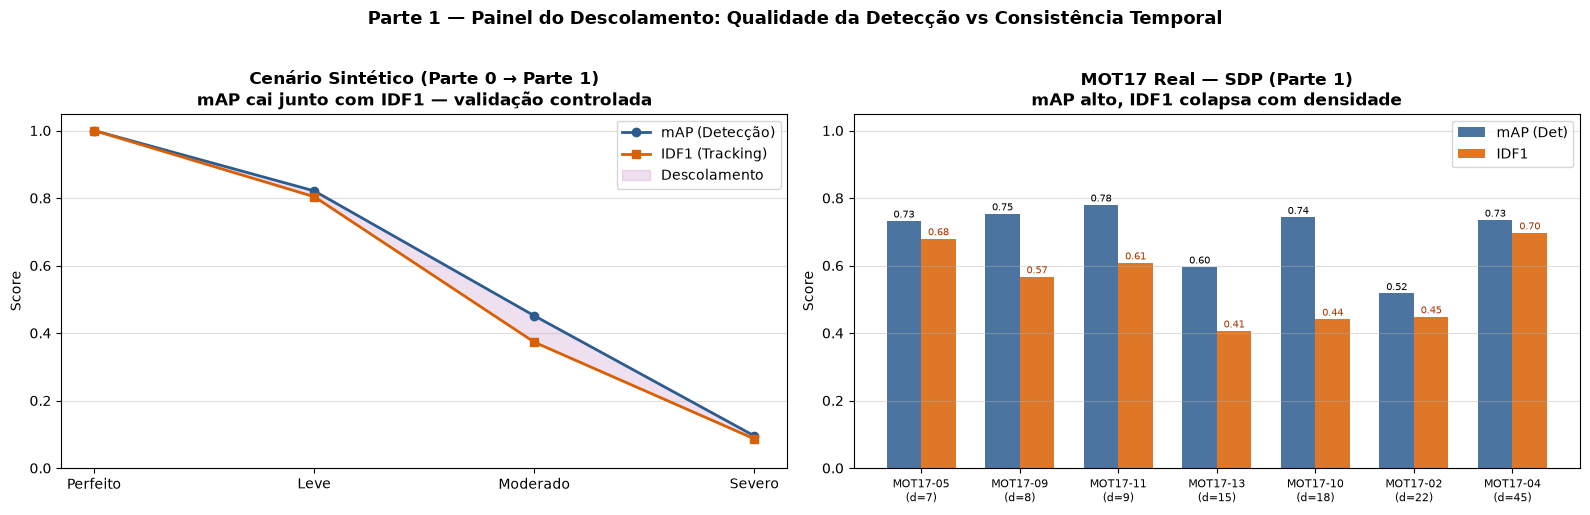

In [7]:
from src.visualization import plot_decoupling_panel

plot_decoupling_panel(synth_results, results_p1, save_path='docs/painel_descolamento_parte1.png')
plt.show()


---
## Parte 2 — Memória Temporal (Trilha A: RNN como Modelo de Movimento)

Substituição da associação ingênua por uma modelagem temporal de movimento:
* A rede recorrente recebe as caixas observadas 0$ e prevê a posição no quadro seguinte;
* Sob oclusão, o estado roda sem observação direta, propagando a previsão no escuro para manter a identidade;
* Perda Smooth L1 sobre as trajetórias ground truth.

In [8]:
# Treinamento do modelo de movimento da Trilha A
# [Espaço para inicializar LSTMMotionModel e executar o treino com Smooth L1 Loss]

### Comparação Direta: Baseline Ingênuo vs Trilha A (Memória Temporal)
Apresentação das métricas lado a lado nas mesmas sequências de teste.

In [9]:
# Tabela comparativa e ganhos de IDF1 e redução de ID switches

---
## Parte 3 — Ablação (Eixo 1: A Célula Recorrente e Janela de BPTT)

Estudo empírico comparando:
* **Células:** RNN Simples vs LSTM vs GRU (orçamento comparável de parâmetros);
* **Janela BPTT truncado:**  \in \{4, 8, 16, 32\}$;
* **Reprodutibilidade:** 3 seeds aleatórias com reporte de $	ext{média} \pm 	ext{desvio padrão}$.

In [10]:
# Execução do grid de ablação multi-seed
# run_ablation_axis1(...)

---
## Parte 4 — Galeria de Falhas e Horizonte de Memória

1. **Medição Analítica:** Norma da derivada $\left\| rac{\partial L_t}{\partial h_{t-k}} 
ight\|$ em função de $ (curva do gradiente que desaparece na RNN simples vs preservado nas portas de LSTM/GRU);
2. **Medição Empírica:** Tempo de sobrevivência do estado sob oclusão vs distribuição de oclusões do dataset;
3. **Galeria de 3 Falhas:** Diagnóstico das quebras estruturais;
4. **Correção:** Implementação de melhoria e avaliação do antes/depois.

In [11]:
# Medição Analítica: Cálculo de ||dL_t / dh_{t-k}|| e plot comparativo
# plot_gradient_vanishing_curves(...)

In [12]:
# Medição Empírica e Apresentação dos 3 Casos de Falha com Correção

---
## Parte 5 — Teste de Estresse (Degradação da Qualidade do Detector)

Aplicação do simulador de detector construído na Parte 0 sobre as detecções do MOT17 em 3 intensidades (leve, moderada, severa):
* Análise se o modelo temporal recorrente **absorve** ou **amplifica** as falhas do detector (reportando mAP e IDF1 juntos).

In [13]:
# Execução do teste de estresse em 3 níveis
# run_detector_stress_test(...)

---
## Síntese dos Resultados e Roteiro da Apresentação Oral
Resumo executivo dos números finais, tabelas e gráficos gerados para a apresentação.